### Turkish Music Emotion

La música desempeña un papel fundamental en la vida humana, ya que tiene la capacidad de despertar o transmitir sentimientos. Dado que el reconocimiento de emociones musicales es objeto de numerosos estudios en diversas disciplinas, como la ciencia, la psicología, la musicología y el arte, ha atraído la atención de los investigadores como un tema de investigación de actualidad en los últimos años. Muchos investigadores extraen características acústicas de la música e investigan las relaciones entre las etiquetas emocionales correspondientes a estas características. Por otro lado, en estudios recientes, los tipos de música se clasifican emocionalmente mediante aprendizaje profundo a través de espectrogramas musicales que incluyen información tanto del dominio temporal como del frecuencial. En el presente estudio, se presenta un nuevo método para el reconocimiento de emociones musicales mediante un modelo de aprendizaje profundo preentrenado con espectrogramas de croma extraídos de grabaciones musicales. Se utiliza la arquitectura AlexNet como modelo de red preentrenado. Las capas conv5, Fc6, Fc7 y Fc8 del modelo AlexNet se seleccionan como capa de extracción de características, y de estas capas se extraen características visuales profundas. Las características profundas extraídas se utilizan para entrenar y probar las Máquinas de Vectores de Soporte (SVM) y los clasificadores Softmax. Además, se extraen características visuales profundas de las capas conv5_3, Fc6, Fc7 y Fc8 del modelo de red profunda VGG-16 y se realizan las mismas aplicaciones experimentales para determinar la eficacia de las redes profundas preentrenadas en el reconocimiento de emociones musicales. Se realizaron varios experimentos con dos conjuntos de datos y se obtuvieron mejores resultados con el método propuesto. El mejor resultado se obtuvo con VGG-16 en la capa Fc7, con un 89,2 % en nuestro conjunto de datos. Según los resultados obtenidos, se observa que el método presentado ofrece un mejor rendimiento.

In [2]:
# Importar las librerias

import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cargar los datasets
original = pd.read_csv('../datasets/input/turkish_music_emotion_original.csv')
modified = pd.read_csv('../datasets/input/turkish_music_emotion_modified.csv')

print('Shape original:', original.shape)
print('Shape modified:', modified.shape)

Shape original: (400, 51)
Shape modified: (408, 52)


In [4]:
# =============================================================
# Exploración inicial (EDA básico)
# =============================================================
print("\nInformación del dataset original:")
print(original.info())

print("\nInformación del dataset modificado:")
print(modified.info())

# Conteo de valores nulos
def resumen_nulos(df):
    nulos = df.isnull().sum()
    return nulos[nulos > 0].sort_values(ascending=False)

print("\nValores nulos en el dataset modificado:")
print(resumen_nulos(modified))


Información del dataset original:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 51 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Class                                           400 non-null    object 
 1   _RMSenergy_Mean                                 400 non-null    float64
 2   _Lowenergy_Mean                                 400 non-null    float64
 3   _Fluctuation_Mean                               400 non-null    float64
 4   _Tempo_Mean                                     400 non-null    float64
 5   _MFCC_Mean_1                                    400 non-null    float64
 6   _MFCC_Mean_2                                    400 non-null    float64
 7   _MFCC_Mean_3                                    400 non-null    float64
 8   _MFCC_Mean_4                                    400 non-null    float64
 9   _MFCC_Me

In [5]:
# =============================================================
# Análisis de inconsistencias de tipo
# =============================================================

# Detección de columnas tipo 'object' que deberían ser numéricas
object_cols = [col for col in modified.columns if modified[col].dtype == 'object' and col != 'Class']
print(f"\nColumnas con tipos 'object' sospechosos: {len(object_cols)}")
print(object_cols[:10])

# Ejemplo de valores únicos para identificar errores
def valores_unicos(df, cols, limit=5):
    for c in cols[:limit]:
        print(f"\n>>> Columna: {c}")
        print(df[c].unique()[:10])

valores_unicos(modified, object_cols)


Columnas con tipos 'object' sospechosos: 37
['_RMSenergy_Mean', '_Tempo_Mean', '_MFCC_Mean_3', '_MFCC_Mean_4', '_MFCC_Mean_5', '_MFCC_Mean_6', '_MFCC_Mean_7', '_MFCC_Mean_8', '_MFCC_Mean_9', '_MFCC_Mean_10']

>>> Columna: _RMSenergy_Mean
['0.052' '0.125' '0.046' '0.135' '0.066' '0.137' '0.123' '0.103' '0.145'
 '0.129']

>>> Columna: _Tempo_Mean
['130.043' '142.24' '188.154' '65.991' '88.89' '116.044' '136.444'
 '141.132' '82.048' '93.02']

>>> Columna: _MFCC_Mean_3
['0.887' '0.785' '0.502' '0.612' '0.814' '0.365' '0.939' '4.95' '0.568'
 '0.537']

>>> Columna: _MFCC_Mean_4
['0.078' '0.397' '0.329' '0.351' '0.096' ' 0.033 ' '0.358' '0.269' '0.559'
 ' -0.116 ']

>>> Columna: _MFCC_Mean_5
['0.221' '0.556' '0.287' '0.011' '0.434' '-0.136' '0.024' ' 0.257 '
 '0.218' '0.119']


In [6]:
# =============================================================
# Conversión de columnas numéricas y manejo de errores
# =============================================================

# Convertir todas las columnas excepto 'Class'
columnas_numericas = modified.columns.difference(['Class', 'mixed_type_col'])
modified[columnas_numericas] = modified[columnas_numericas].apply(pd.to_numeric, errors='coerce')

# Eliminar la columna
modified = modified.drop('mixed_type_col', axis=1, errors='ignore')

# Revisión de nulos post conversión
print("\nValores nulos después de conversión a numéricos:")
print(resumen_nulos(modified))


Valores nulos después de conversión a numéricos:
_MFCC_Mean_3                                      12
_MFCC_Mean_11                                     12
_MFCC_Mean_12                                     11
_RMSenergy_Mean                                   10
_Tempo_Mean                                        9
_MFCC_Mean_5                                       9
_Spectralskewness_Mean                             9
_HarmonicChangeDetectionFunction_Mean              9
_Chromagram_Mean_5                                 8
_MFCC_Mean_4                                       8
_MFCC_Mean_10                                      8
_Spectralcentroid_Mean                             8
_HarmonicChangeDetectionFunction_PeriodEntropy     8
_HarmonicChangeDetectionFunction_Slope             8
_Pulseclarity_Mean                                 7
_Chromagram_Mean_1                                 7
_Chromagram_Mean_7                                 7
_Chromagram_Mean_11                              

In [7]:
# =============================================================
# Corrección de valores mal formateados en columnas numéricas
# =============================================================

for col in modified.columns:
    if col != 'Class':
        # Convertir a string temporalmente
        modified[col] = modified[col].astype(str)
        # Quitar comas al final o caracteres extraños
        modified[col] = modified[col].str.replace(',', '', regex=False)
        # Intentar convertir nuevamente a numérico
        modified[col] = pd.to_numeric(modified[col], errors='coerce')


In [8]:

# =============================================================
#  Limpieza de valores nulos
# =============================================================

# Estrategia: imputar valores numéricos con la mediana
for col in modified.columns:
    if modified[col].dtype in ['float64', 'int64']:
        modified[col].fillna(modified[col].median(), inplace=True)

# Eliminar filas sin clase
modified.dropna(subset=['Class'], inplace=True)

C:\Users\Gabo\AppData\Local\Temp\ipykernel_31584\281845979.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  modified[col].fillna(modified[col].median(), inplace=True)
C:\Users\Gabo\AppData\Local\Temp\ipykernel_31584\281845979.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [9]:
# =============================================================
#  Detección y tratamiento de outliers
# =============================================================

# Método IQR (Interquartile Range)
def eliminar_outliers(df, columnas, k=3):
    for c in columnas:
        if df[c].dtype in ['float64', 'int64']:
            Q1 = df[c].quantile(0.25)
            Q3 = df[c].quantile(0.75)
            IQR = Q3 - Q1
            low = Q1 - k * IQR
            high = Q3 + k * IQR
            df = df[(df[c] >= low) & (df[c] <= high)]
    return df

modified_clean = eliminar_outliers(modified, modified.columns[1:])
print(f"\nDataset final sin outliers: {modified_clean.shape}")


Dataset final sin outliers: (227, 51)


In [10]:
# =============================================================
# Normalización de la columna Class
# =============================================================

# Convertir todo a minúsculas
modified_clean['Class'] = modified_clean['Class'].str.strip().str.lower()

# Revisar distribución después de la corrección
print(modified_clean['Class'].value_counts())

Class
happy    60
sad      58
relax    57
angry    52
Name: count, dtype: int64


C:\Users\Gabo\AppData\Local\Temp\ipykernel_31584\3688521958.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=modified_clean, palette='viridis')


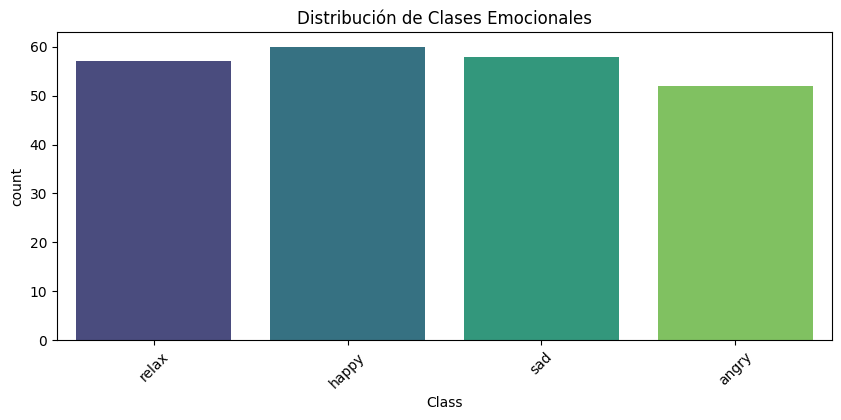

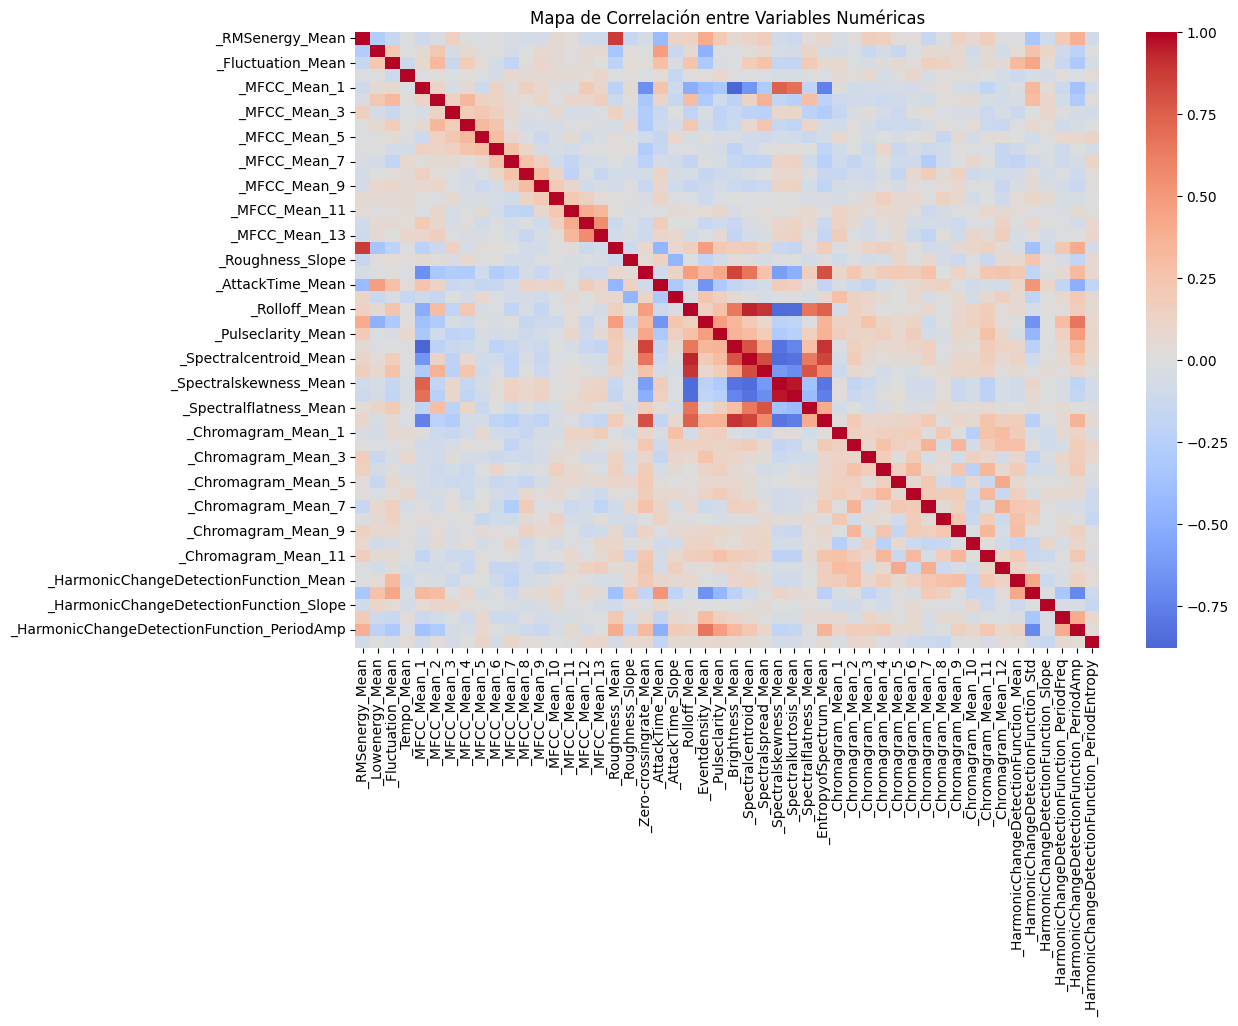

In [11]:
# =============================================================
#  Análisis exploratorio (visual)
# =============================================================

plt.figure(figsize=(10, 4))
sns.countplot(x='Class', data=modified_clean, palette='viridis')
plt.title('Distribución de Clases Emocionales')
plt.xticks(rotation=45)
plt.show()

# Correlación entre variables numéricas
corr = modified_clean.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Mapa de Correlación entre Variables Numéricas')
plt.show()

In [13]:
# =============================================================
#  Exportación del dataset limpio
# =============================================================
modified_clean.to_csv('../datasets/output/EDA_cleaned.csv', index=False)
print("\n Dataset limpio exportado como 'EDA_cleaned.csv'")




 Dataset limpio exportado como 'EDA_cleaned.csv'


In [11]:
# Inicializar MLFlow Server

mlflow.set_tracking_uri("http://127.0.0.1:8080")
mlflow.set_experiment("01 - Turkish Music Emotion")
mlflow.sklearn.autolog()

In [12]:
# Cargar Turkish Music Emotion Dataset

# Cargar el dataset
df = pd.read_csv("../datasets/input/turkish_music_emotion_original.csv")

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nClass distribution:")
print(df['Class'].value_counts())

print("\nDataset info:")
print(df.info())

Dataset shape: (400, 51)

First few rows:
   Class  _RMSenergy_Mean  _Lowenergy_Mean  _Fluctuation_Mean  _Tempo_Mean  \
0  relax            0.052            0.591              9.136      130.043   
1  relax            0.125            0.439              6.680      142.240   
2  relax            0.046            0.639             10.578      188.154   
3  relax            0.135            0.603             10.442       65.991   
4  relax            0.066            0.591              9.769       88.890   

   _MFCC_Mean_1  _MFCC_Mean_2  _MFCC_Mean_3  _MFCC_Mean_4  _MFCC_Mean_5  ...  \
0         3.997         0.363         0.887         0.078         0.221  ...   
1         4.058         0.516         0.785         0.397         0.556  ...   
2         2.775         0.903         0.502         0.329         0.287  ...   
3         2.841         1.552         0.612         0.351         0.011  ...   
4         3.217         0.228         0.814         0.096         0.434  ...   

   _Chro

In [13]:
# Data Preprocessing y Model Training

# Separar features y target
X = df.drop('Class', axis=1)
y = df['Class']

# Encode la variable target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Separar los datos en training y test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

# Crear nombre único con timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_name = f"turkish_music_emotion_{timestamp}"

print(f"Starting run: {run_name}")

# Entrenar y evaluar el modelo
with mlflow.start_run(run_name=run_name):
    # Entrenar el modelo Random Forest
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Calcular accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("timestamp", timestamp)
    
    print(f"Model Accuracy: {accuracy:.4f}")
    print(f"Run Name: {run_name}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # Log the model
    mlflow.sklearn.log_model(model, "model")

Training set size: 320
Test set size: 80
Number of features: 50
Starting run: turkish_music_emotion_20251001_115928


2025/10/01 11:59:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model Accuracy: 0.7625
Run Name: turkish_music_emotion_20251001_115928

Classification Report:
              precision    recall  f1-score   support

       angry       0.88      0.75      0.81        20
       happy       0.80      1.00      0.89        20
       relax       0.68      0.75      0.71        20
         sad       0.69      0.55      0.61        20

    accuracy                           0.76        80
   macro avg       0.76      0.76      0.76        80
weighted avg       0.76      0.76      0.76        80



2025/10/01 11:59:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run turkish_music_emotion_20251001_115928 at: http://127.0.0.1:8080/#/experiments/200394103665423037/runs/68827f41ad804dd4830fec8121860a8b
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/200394103665423037
